<h1>Balancing The Last of Us: The Last Stand</h1>
<p><i>A data-driven balancing framework using metrics, statistics, and systems analysis.</i></p>

In [1]:
import random
import math
import json
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pathEffects
import re

from collections import defaultdict
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from gameData import CHARACTERS, CHARACTERSTWO, SUPPORTS, standardCharacterDeck, standardSupportDeck

<h2><u>Expected Value (EV) and Performance Value (PV)<u></h2>

<h3>Why Calculate Two Values?</h3>

Balancing a system with interactive cards requires more than looking at base stats. Cards in The Last Stand derive value from:

<ul>
<li>Intrinsic power, or its base value</li>
<li>Perk triggers</li>
<li>Support play</li>
<li>Conditional outcomes (victory, loss, or tie)</li>
<li>Player behavior patterns</li>
</ul>

Because of this complexity, static analysis is insufficient. To understand real card strength, I simulate gameplay scenarios and measure performance across many iterations. This allows me to get a estimate for the average impact of cards to better balance their effectiveness in-game.<br>

<p><i>Note: Both EV and PV are calculated in games that have no modifiers.</i></p>

<h3>Expected Value (EV)</h3>

The Expected Value (EV) of a card is its simulated mean performance across n iterations.

It measures how strong a card is in expectation, given all system interactions.

Formally:

$$EV = \frac{\sum_{i=1}^{n} (B + S_i + U_i + C_i)}{n}$$

Where:
- $B$ is the Base Value (The number on the card itself)
- $S_i$ is the Synergy Value (The sum of all triggered perks)
- $U_i$ is the Utility Value (The value of the highest matching support card)
- $C_i$ is the Conditional Outcome (Any post combat weight from battle results)

In [ ]:
def calculateCharacterExpectedValue(iterations=100000, database=CHARACTERS):
    cardHistories = defaultdict(list)

    for _ in range(iterations):
        # Assuming standardCharacterDeck and standardSupportDeck are defined globally
        characterDeck = standardCharacterDeck[:]
        supportDeck = standardSupportDeck[:]
        
        # Player Hand
        playerCharacters = [characterDeck.pop(random.randrange(len(characterDeck))) for _ in range(4)]
        playerSupports = [supportDeck.pop(random.randrange(len(supportDeck))) for _ in range(4)]
        
        # Draw 1 Opponent Character Card
        opponentCharacterName = characterDeck.pop(random.randrange(len(characterDeck)))
        opponentValue, opponentFaction, opponentTypes, opponentPerk = database[opponentCharacterName]
        
        # Simulate opponent support play (80% chance they play an average +3 support, 20% chance they play nothing)
        opponentPlayedSupport = random.random() > 0.2
        opponentTotal = opponentValue + (3 if opponentPlayedSupport else 0)

        # Evaluate all cards in the players hand
        for characterName in playerCharacters:
            baseValue, faction, types, perks = database[characterName]
            realizedValue = baseValue
            characterTypes = types.split('/')

            # PRE-COMBAT PERKS
            for perkType, target, perkValue, condition in perks:
                if perkType == "hand_bonus" and target in playerCharacters:
                    realizedValue += perkValue
                
                elif perkType == "scaling":
                    if condition == "hand": 
                        count = sum(1 for character in playerCharacters if database[character][1] == target) - 1
                        realizedValue += (count * perkValue)
                    elif condition == "hand_name": 
                        count = sum(1 for character in playerCharacters if character == target) - 1
                        realizedValue += (count * perkValue)

                elif perkType == "vs_faction" and opponentFaction == target:
                    realizedValue += perkValue
                
                elif perkType == "vs_type" and any(typeItem in opponentTypes for typeItem in target.split('/')):
                    realizedValue += perkValue
                
                elif perkType == "solo_bonus":
                    if not any(database[character][1] == target for character in playerCharacters if character != characterName):
                        realizedValue += perkValue

                elif perkType == "debuff_vs_type":
                    if any(typeItem in opponentTypes for typeItem in target.split('/')):
                        realizedValue -= perkValue
                                
                elif perkType == "vs_value_min" and opponentValue >= target:
                    realizedValue += perkValue
                    
                elif perkType == "vs_value_max" and opponentValue <= target:
                    realizedValue += perkValue
                    
                elif perkType == "no_type_in_hand":
                    if not any(target in database[c][2].split('/') for c in playerCharacters):
                        realizedValue += perkValue
                        
                elif perkType == "no_enemy_support" and not opponentPlayedSupport:
                    realizedValue += perkValue
                    
                elif perkType == "vs_multi_type" and '/' in opponentTypes:
                    realizedValue += perkValue
                    
                elif perkType == "equalize" and any(typeItem in opponentTypes for typeItem in target.split('/')):
                    realizedValue = max(realizedValue, opponentValue)
                    realizedValue += perkValue

            # SUPPORT RESOLUTION
            bestSupportValue = 0
            for supportName in playerSupports:
                supportData = SUPPORTS[supportName]
                supportValue = supportData[0]
                supportTypes = supportData[2]
                
                currentSupportValue = supportValue
                
                for perkType, target, perkValue, condition in perks:
                    if perkType == "support_bonus" and supportName == target:
                        currentSupportValue += perkValue
                    
                    elif perkType == "support_class_bonus" and any(typeItem in supportTypes for typeItem in target.split('/')):
                        currentSupportValue += perkValue

                supportTypeList = supportTypes.split('/')
                if any(typeItem in supportTypeList for typeItem in characterTypes):
                    bestSupportValue = max(bestSupportValue, currentSupportValue)
            
            realizedValue += bestSupportValue

            # CONDITIONAL PERKS (Post-Combat Check)
            for perkType, target, perkValue, condition in perks:
                if perkType == "on_win" and realizedValue > opponentTotal:
                    realizedValue += perkValue
                
                elif perkType == "on_heavy_loss" and (opponentTotal - realizedValue) >= 2:
                    realizedValue += perkValue
                
                elif perkType == "tie_bonus" and realizedValue == opponentTotal:
                    realizedValue += perkValue
                    
                elif perkType == "on_loss_buff_hand" and realizedValue < opponentTotal:
                    realizedValue += perkValue
            
            # Record the final evaluated score
            cardHistories[characterName].append(realizedValue)

    # Prepare the final data
    finalResults = []
    for characterName, outcomes in cardHistories.items():
        averageExpectedValue = sum(outcomes) / len(outcomes)
        baseValue = database[characterName][0]
        
        finalResults.append((
            characterName, 
            baseValue, 
            round(averageExpectedValue, 2),
            round(averageExpectedValue - baseValue, 2)
        ))

    return sorted(finalResults, key=lambda x: x[2], reverse=True)

expectedValueData = calculateCharacterExpectedValue(100000, CHARACTERS)

In [7]:
# Optional: Run this to view the table of expected values
print(f"{'CARD NAME':<18} | {'BASE':<5} | {'EV':<5} | {'VALUE ADD'}")
print("-" * 50)
for name, base, ev, difference in expectedValueData:
    print(f"{name:<18} | {base:<5} | {ev:<5.2f} | +{difference:.2f}")

CARD NAME          | BASE  | EV    | VALUE ADD
--------------------------------------------------
RatKing            | 8     | 14.09 | +6.09
Joel               | 6     | 10.27 | +4.27
Isaac              | 6     | 9.82  | +3.82
Abby               | 6     | 9.25  | +3.25
TheProphet         | 6     | 9.23  | +3.23
Lev                | 3     | 8.96  | +5.96
Clicker            | 5     | 8.49  | +3.49
SeraphiteBrute     | 5     | 8.40  | +3.40
TommyFirefly       | 4     | 8.06  | +4.06
Marlene            | 5     | 8.05  | +3.05
Riley              | 3     | 8.03  | +5.03
Manny              | 4     | 7.82  | +3.82
Ellie              | 5     | 7.80  | +2.80
Tommy              | 5     | 7.72  | +2.72
Jessie             | 5     | 7.60  | +2.60
Stalker            | 3     | 7.48  | +4.48
Bloater            | 4     | 7.40  | +3.40
Eugene             | 3     | 7.37  | +4.37
Bill               | 4     | 7.19  | +3.19
Dina               | 3     | 7.11  | +4.11
Ezra               | 3     | 6.97  | +3.97

<h3>Performance Value (PV)</h3>

While EV measures expected strength, Performance Value (PV) measures how the card actually performs under real recorded gameplay data.

If EV represents theoretical simulation output, PV represents observed performance. This is data gathered from local playtests.

<p><i>Note: To ensure statistical reliability, most cards are required to reach a minimum of approximately 30 plays before their Performance Value (PV) is considered stable. This threshold reduces variance noise, improves confidence in observed averages, and ensures meaningful comparison between cards. Cards with fewer observations may produce volatile or unreliable PV estimates.</i></p>

In [8]:
def calculateCharacterPlayedValue(fileSourcePath):
    try:
        with open(fileSourcePath, 'r') as fileHandle:
            fullGameSessionData = json.load(fileHandle)
    except FileNotFoundError:
        print(f"Error: {fileSourcePath} not found.")
        return {}

    playedValueHistory = defaultdict(list)
    characterSampleCounts = defaultdict(int)

    for sessionId, games in fullGameSessionData.items():
        for individualGame in games:
            if individualGame.get("activeModifiers"): continue # Skip modified games

            # Filter for character-only sequences to find the match-ups
            pChars = [c for c in individualGame.get("cardsPlayed", []) if c["faction"] != "Support"]
            oChars = [c for c in individualGame.get("opponentCards", []) if c["faction"] != "Support"]

            # General outcome data for on_win/on_loss perks
            playerWon = individualGame.get("totalForcePlayer", 0) > individualGame.get("totalForceOpponent", 0)
            opponentWon = individualGame.get("totalForceOpponent", 0) > individualGame.get("totalForcePlayer", 0)
            isTie = individualGame.get("totalForcePlayer", 0) == individualGame.get("totalForceOpponent", 0)
            pHeavyLoss = (individualGame.get("totalForceOpponent", 0) - individualGame.get("totalForcePlayer", 0)) >= 2.0
            oHeavyLoss = (individualGame.get("totalForcePlayer", 0) - individualGame.get("totalForceOpponent", 0)) >= 2.0

            # Iterate through the pairs (zip stops at the shorter list, matching the round count)
            for pCard, oCard in zip(pChars, oChars):
                pName, oName = pCard["cardKey"], oCard["cardKey"]
                
                # --- Process Player Side ---
                if pName in CHARACTERS:
                    pImpact = pCard["value"]
                    pData = CHARACTERS[pName]
                    oData = CHARACTERS.get(oName, [0, "None", "None", []])
                    
                    # Manual Debuff Check: If player debuffs opponent, player gets the 'Impact'
                    for pType, target, pVal, cond in pData[3]:
                        if pType == "debuff_vs_type" and any(t in oData[2] for t in target.split('/')):
                            pImpact += abs(pVal)
                        
                        # Add standard conditional perks
                        elif pType == "on_win" and playerWon: pImpact += pVal
                        elif pType == "on_heavy_loss" and pHeavyLoss: pImpact += pVal
                        elif pType == "tie_bonus" and isTie: pImpact += pVal

                    playedValueHistory[pName].append(pImpact)
                    characterSampleCounts[pName] += 1

                # --- Process Opponent Side ---
                if oName in CHARACTERS:
                    oImpact = oCard["value"]
                    oData = CHARACTERS[oName]
                    pData = CHARACTERS.get(pName, [0, "None", "None", []])

                    for pType, target, pVal, cond in oData[3]:
                        if pType == "debuff_vs_type" and any(t in pData[2] for t in target.split('/')):
                            oImpact += abs(pVal)
                        
                        elif pType == "on_win" and opponentWon: oImpact += pVal
                        elif pType == "on_heavy_loss" and oHeavyLoss: oImpact += pVal
                        elif pType == "tie_bonus" and isTie: oImpact += pVal

                    playedValueHistory[oName].append(oImpact)
                    characterSampleCounts[oName] += 1

    finalResults = {name: sum(vals)/len(vals) for name, vals in playedValueHistory.items()}
    return finalResults, characterSampleCounts

playedValueData, characterPlayCounts = calculateCharacterPlayedValue("game_balance_data.json")

In [105]:
# Optional: Run this to view the table of played values
print(f"\n{'CHARACTER':<18} | {'PV':<5} | {'n (Plays)'}")
print("-" * 40)

sortedCharacterResults = sorted(playedValueData.items(), key=lambda item: item[1], reverse=True)

for characterName, averageValue in sortedCharacterResults:
    playCount = characterPlayCounts[characterName]
    print(f"{characterName:<18} | {averageValue:<5.2f} | {playCount}")

print("-" * 40)
totalDataPoints = sum(characterPlayCounts.values())
print(f"TOTAL CLEAN DATA POINTS: {totalDataPoints}")


CHARACTER          | PV    | n (Plays)
----------------------------------------
RatKing            | 11.32 | 34
Isaac              | 8.69  | 26
Abby               | 7.67  | 21
Jessie             | 7.13  | 31
Joel               | 7.05  | 38
TheProphet         | 7.00  | 28
Clicker            | 6.89  | 47
TommyFirefly       | 6.71  | 21
Bloater            | 6.58  | 26
Manny              | 6.43  | 28
Marlene            | 6.12  | 26
Emily              | 5.79  | 19
Ellie              | 5.70  | 30
Malik              | 5.48  | 23
WLFSoldier         | 5.46  | 39
Tommy              | 5.43  | 28
SeraphiteBrute     | 5.37  | 41
Stalker            | 5.34  | 61
Bill               | 4.87  | 23
Ezra               | 3.92  | 26
Yara               | 3.72  | 25
Nora               | 3.69  | 26
FireflySoldier     | 3.60  | 48
Riley              | 3.50  | 16
Li                 | 3.50  | 18
Lev                | 3.45  | 20
Dina               | 3.43  | 30
Alice              | 3.21  | 19
Runner             | 3.

<h3>Card Meta Visualization</h3>


Card Meta report saved successfully as 'last_stand_card_meta.png'.


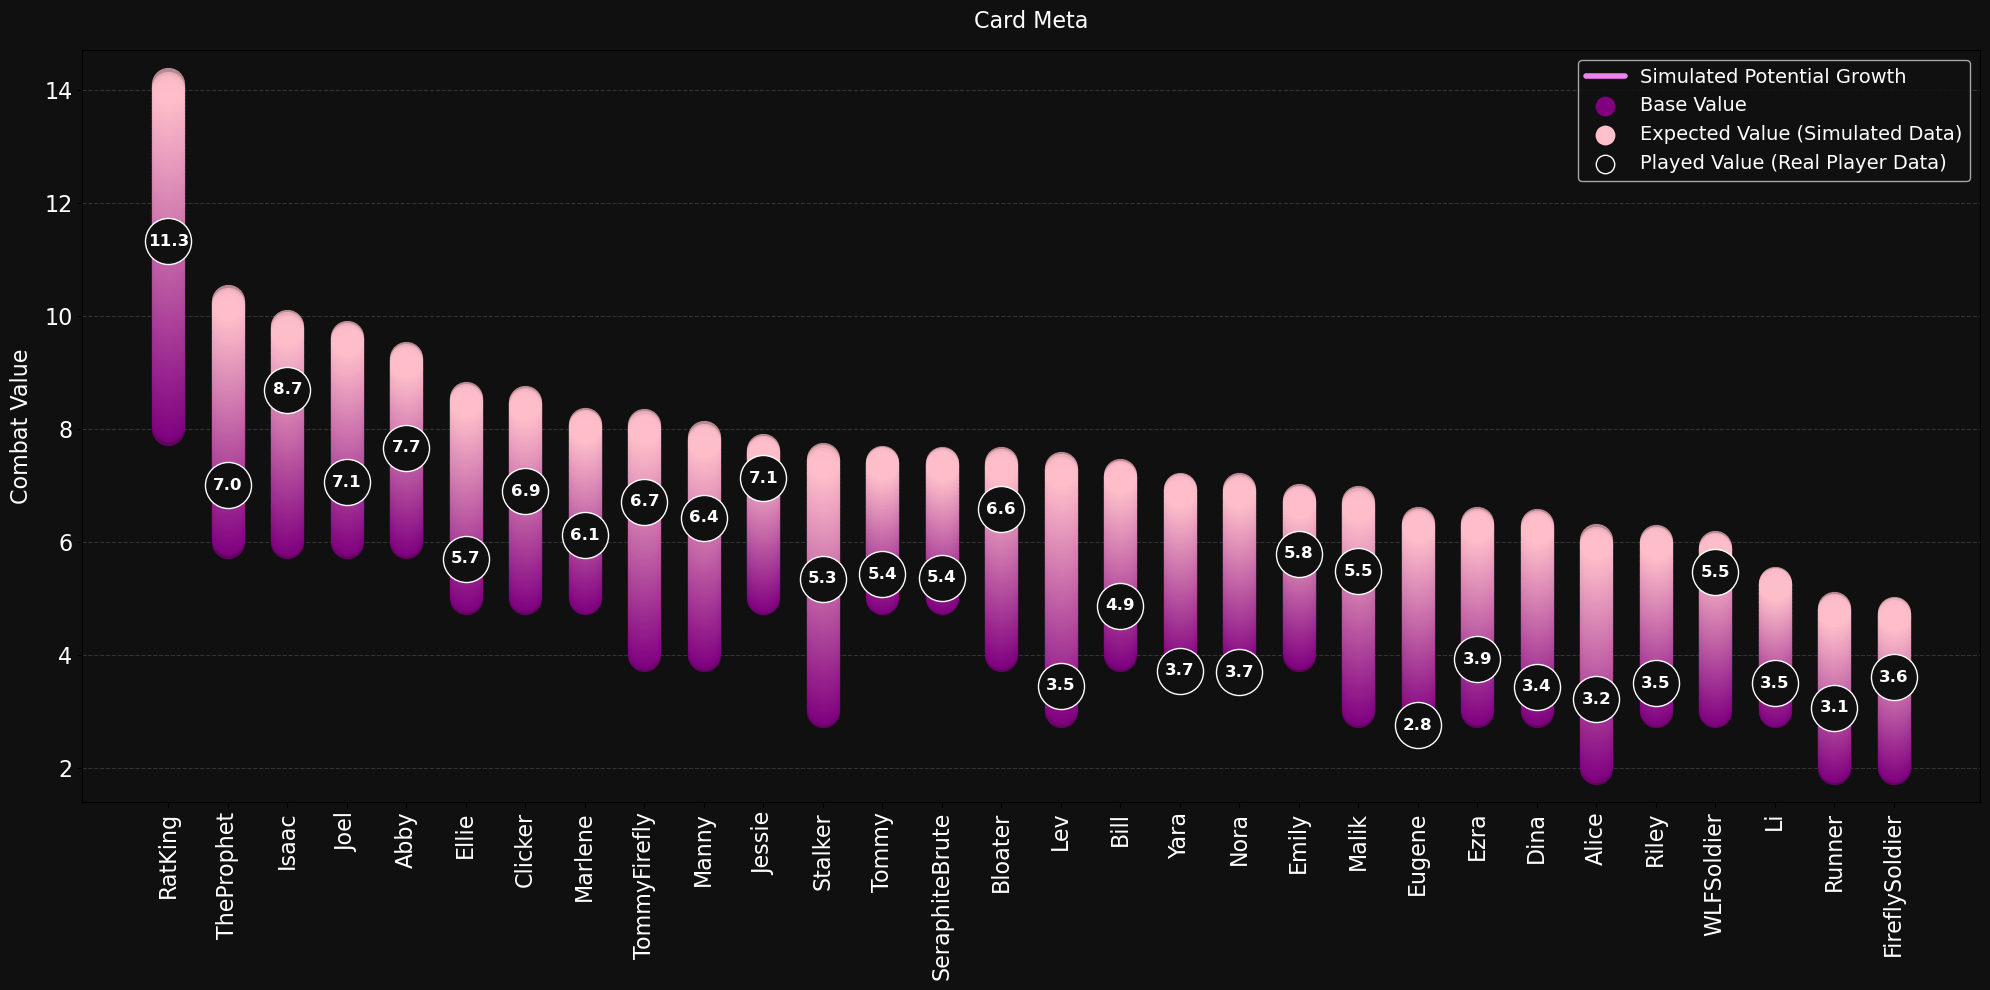

In [11]:
def plotMetaLollipopVisualization(expectedValueResults, playedValueResults):
    characterNames = [item[0] for item in expectedValueResults]
    baseValues = [item[1] for item in expectedValueResults]
    expectedValueValues = [item[2] for item in expectedValueResults]
    playedValueValues = [playedValueResults.get(name) for name in characterNames]

    plt.figure(figsize=(20, 10), facecolor='#101010')
    currentAxes = plt.gca()
    currentAxes.set_facecolor('#101010') 
    xPositions = range(len(characterNames))

    # Growth Lines
    colorStartHex = "#800080" 
    colorEndHex = "#ffc0cb"
    customColorList = [colorStartHex, colorEndHex]
    customColorMap = LinearSegmentedColormap.from_list("lastStandGradient", customColorList)

    for index in range(len(characterNames)):
        startY = baseValues[index]
        endY = expectedValueValues[index]
        xPosition = xPositions[index]

        gradientPointsY = np.linspace(startY, endY, 100)
        gradientPointsX = np.full_like(gradientPointsY, xPosition)
        
        segments = np.array([gradientPointsX, gradientPointsY]).T.reshape(-1, 1, 2)
        segments = np.concatenate([segments[:-1], segments[1:]], axis=1)

        lineCollection = LineCollection(segments, cmap=customColorMap, linewidth=24, alpha=0.7, capstyle='round')
        
        lineCollection.set_array(gradientPointsY)
        
        plt.gca().add_collection(lineCollection)

    # Add a single proxy artist for the legend (since LineCollections can't easily share one legend label)
    plt.plot([], [], color="#ee82ee", linewidth=4, solid_capstyle='round', label='Simulated Potential Growth')

    # Hidden endpoints
    plt.scatter([np.nan], [np.nan], color=colorStartHex, label='Base Value', zorder=3, s=1100)
    
    plt.scatter([np.nan], [np.nan], color=colorEndHex, label='Expected Value (Simulated Data)', zorder=4, s=1100)
    
    # Played Value
    # Filter out characters with no real-world play data to avoid plotting None values
    playedValueXPositions = [x for x, value in zip(xPositions, playedValueValues) if value is not None]
    playedValueYValues = [value for value in playedValueValues if value is not None]

    plt.scatter(
        playedValueXPositions, 
        playedValueYValues, 
        color="#101010", 
        alpha=1, 
        s=1100,
        label='Played Value (Real Player Data)', 
        edgecolors='white', 
        marker='o',
        zorder=5
    )

    # Played value number in circle
    for xPosition, yValue in zip(playedValueXPositions, playedValueYValues):
        plt.text(
            xPosition, 
            yValue, 
            f"{yValue:.1f}",
            color='white', 
            fontsize=12, 
            fontweight='bold',
            ha='center', 
            va='center', 
            zorder=6
        )

    # Graph styling
    plt.yticks(fontsize=16, color='white')
    plt.xticks(xPositions, characterNames, rotation='vertical', fontsize=16, color='white') 
    plt.ylabel('Combat Value', fontsize=16, labelpad=8, color='white')
    plt.title('Card Meta', fontsize=16, pad=16, color='white')
    plt.grid(axis='y', linestyle='--', alpha=0.15, color='white')
    plt.legend(loc='upper right', frameon=True, facecolor="#101010", markerscale=0.4, fontsize=14, labelcolor='white')

    plt.tight_layout()
    plt.savefig('finalGraphs/last_stand_card_meta.png', dpi=300)
    print("\nCard Meta report saved successfully as 'last_stand_card_meta.png'.")

plotMetaLollipopVisualization(expectedValueData, playedValueData)

<h3>Explaining the Visualization</h3>

The graph is ordered from left to right by descending Expected Value (EV). This ranking creates a strength curve that reflects the simulated performance hierarchy of all cards in the system.

The vertical growth lines (Base → EV) represent how much value each card gains through synergy, utility interactions, and conditional effects. Greater variation in line length indicates greater differences in simulated scaling potential. If multiple cards display similar line lengths and EV positions, it suggests that the simulation evaluates them as having comparable interaction-driven strength.

The Played Value (PV) markers represent real gameplay outcomes derived from playtest data. In a balanced system, PV values should generally fall within the range bounded by the Base Value and the Expected Value, since EV represents the simulated performance ceiling under defined conditions. Deviations beyond this range indicate underperformance (PV below expectation) or overperformance (PV exceeding expectation), highlighting potential balance discrepancies or meta effects.

The distribution pattern of PV values provides insight into player influence. If PV markers closely follow the EV trend, this suggests strong alignment between simulation and real-world play, indicating that system predictions are reliable. In contrast, greater dispersion or wave-like variation in PV values reflects player-driven factors such as strategic preferences, optimization differences, and meta adaptation. This divergence quantifies the extent to which player behavior modifies theoretical balance outcomes.<br><br>

<p><b>What would an ideal system look like?</b></p><br>
The EV curve would form a smooth and continuous downward trend, reflecting a stable and gradual strength distribution across cards. Growth lines from Base Value to EV would vary appropriately, showing meaningful differences in synergy potential without extreme outliers. The Played Value (PV) markers would closely align with their corresponding EV values, indicating strong agreement between simulation and real gameplay. Most PV values would remain within the Base–EV range, demonstrating controlled deviation and a healthy Realization Gap. Overall, the graph would show consistent balance, structured variation, and strong alignment between design intent and observed performance.

<h2><u>Strategic Analysis<u></h2>

In [13]:
def generateStrategicReport(expectedValueResults, playedValueResults, characterSampleCounts):
    print("Strategic Report")
    print("-" * 55)

    synergyDeltas = []

    for characterName, baseValue, expectedValue, valueAdded in expectedValueResults:
        synergyDeltas.append(valueAdded)

    averageSynergyCoefficient = np.mean(synergyDeltas)
    synergyVolatility = np.std(synergyDeltas)

    print(f"Average Synergy Coefficient: {averageSynergyCoefficient:.3f}")
    print(f"Synergy Volatility:          {synergyVolatility:.3f}\n")

    totalPlays = sum(characterSampleCounts.values())

    deck_shares = []
    for plays in characterSampleCounts.values():
        if totalPlays > 0:
            deck_shares.append(plays / totalPlays)

    entropy = 0
    for p in deck_shares:
        entropy -= p * math.log2(p) if p > 0 else 0

    hhi = sum([p**2 for p in deck_shares])

    print(f"Deck Entropy:                {round(entropy,4)}")
    print(f"Deck Concentration (HHI):    {round(hhi,6)}\n")

    gaps = []

    for characterName, baseValue, expectedValue, _ in expectedValueResults:
        playedValue = playedValueResults.get(characterName)

        if playedValue is not None:
            gaps.append(abs(expectedValue - playedValue))

    averageGap = np.mean(gaps) if gaps else 0

    print(f"Average Realization Gap:     {round(averageGap,4)}\n")

    performance_values = []

    for characterName in playedValueResults:
        if playedValueResults.get(characterName) is not None:
            performance_values.append(playedValueResults[characterName])

    performance_spread = np.std(performance_values) if performance_values else 0

    print(f"Performance Spread:          {round(performance_spread,4)}\n")

    meta_impacts = []

    for characterName, plays in characterSampleCounts.items():
        playedValue = playedValueResults.get(characterName)

        if playedValue is not None and totalPlays > 0:
            deck_share = plays / totalPlays
            impact = playedValue * deck_share

            meta_impacts.append((characterName, round(impact,4)))

    meta_impacts.sort(key=lambda x: x[1], reverse=True)

    print("-" * 55)

    if synergyVolatility < 1.0:
        synergyConclusion = "Low volatility — Base stats strongly influence outcomes."
    elif synergyVolatility <= 2.9:
        synergyConclusion = "Strategic volatility — Skill meaningfully affects outcomes."
    else:
        synergyConclusion = "Chaotic volatility — Strategy is difficult to predict."

    if hhi < 0.05:
        metaState = "Extremely diverse meta with no dominant card."
    elif hhi < 0.10:
        metaState = "Healthy meta diversity with mild concentration."
    else:
        metaState = "Meta concentration present. Some cards shape ecosystem behavior."

    if synergyVolatility < 1.0 and averageGap < 1.5:
        systemState = "Stable and stat-driven with limited volatility."
    elif synergyVolatility <= 2.9 and averageGap <= 2.5:
        systemState = "Strategically healthy. Skill meaningfully shapes outcomes without destabilizing balance."
    elif synergyVolatility > 2.9:
        systemState = "High systemic volatility. Strategic predictability is reduced."
    else:
        systemState = "Balanced but leaning toward design-dominant outcomes."

    
    print("Synergy Analysis:")
    print(synergyConclusion)

    print("\nDeck Analysis:")
    print(metaState)

    print("\nSystem Analysis:")
    print(systemState)

generateStrategicReport(expectedValueData, playedValueData, characterPlayCounts)

Strategic Report
-------------------------------------------------------
Average Synergy Coefficient: 3.646
Synergy Volatility:          0.914

Deck Entropy:                4.8236
Deck Concentration (HHI):    0.037543

Average Realization Gap:     2.3165

Performance Spread:          1.9157

-------------------------------------------------------
Synergy Analysis:
Low volatility — Base stats strongly influence outcomes.

Deck Analysis:
Extremely diverse meta with no dominant card.

System Analysis:
Strategically healthy. Skill meaningfully shapes outcomes without destabilizing balance.


<hr>

<h3>Explaining The Strategic Report</h3>
<p><i>Click to expand each figure.</i></p><br>

<details>
<summary>Average Synergy Coefficient</summary><br>

The average amount of value added by synergy across all cards.

| Value | Description |
| :--- | :--- |
| 0.0 - 1.0 | Minimal synergy influence. Game is primarily base-stat driven. |
| 1.0 - 2.5 | Moderate synergy presence. Strategy meaningfully affects outcomes. |
| 2.5 - 4.0 | Strong synergy system. Interactions significantly shape performance. |
| 4.0+ | Synergy dominates design. Outcomes are heavily interaction-dependent. |

</details><br>

<details>
<summary>Synergy Volatility</summary><br>

The standard deviation of synergy value added across cards. It is the spread of synergic ceilings.

| Value | Description |
| :--- | :--- |
| 0.0 - 1.0 | Cards have similar synergy ceilings. Strategy exists through interactions. |
| 1.0 - 2.0 | Skill expression increases and stronger cards can outperform weaker ones with good play. |
| 2.0 - 3.0 | Large ceiling gaps where synergy can heavily swing outcomes. Balancing is more challenging. |
| 3.0+ | Cards vastly outscale others. Swings are so large they cannot be overcome. |

</details><br>

<details>
<summary>Deck Entropy</summary><br>

A measure of diversity in card usage distribution. Higher entropy = more evenly distributed play.

Maximum possible entropy for 38 (current total character cards in deck) equally distributed cards is: 
$$log_2(38)≈ 5.25$$

| Value | Description |
| :--- | :--- |
| 0.0 - 2.0 | Highly concentrated usage. Few cards dominate. |
| 2.0 - 3.5 | Moderate diversity. Clear meta preferences exist. |
| 3.5 - 4.8 | High diversity. Most cards see meaningful play. |
| 4.8 - 5.25 | Extremely balanced distribution. Near-maximum diversity. |

</details><br>

<details>
<summary>Deck Concentration (HHI)</summary><br>

Herfindahl–Hirschman Index of play distribution. Measures dominance.

For 38 cards, the minimum theoretical HHI (perfectly even): 
$$1/38≈0.0263$$

| Value | Description |
| :--- | :--- |
| 0.026 - 0.05 | Near-uniform distribution. Extremely healthy. |
| 0.05 - 0.10 | Mild concentration. Some meta shaping. |
| 0.10 - 0.20 | Clear dominance emerging. |
| 0.20+ | Strong centralization. Meta risk. |

</details><br>

<details>
<summary>Average Realization Gap</summary><br>

The average absolute difference between expected value and actual played value. It measures how much player behavior alters outcomes.

| Value | Description |
| :--- | :--- |
| 0.0 - 1.0 | Design dominates. Outcomes mostly predictable. |
| 1.0 - 2.0 | Healthy strategic influence. Skill matters. |
| 2.0 - 3.0 | Strong optimization layer. Meta adapts. |
| 3.0+ | Player behavior heavily overrides design intent. |

</details><br>

<details>
<summary>Performance Spread</summary><br>

Measures how widely character performance differs.

| Value | Description |
| :--- | :--- |
| 0.0 - 1.0 | Tight balance. Characters perform similarly. |
| 1.0 - 2.0 | Moderate differentiation. Clear tier structure begins forming. |
| 2.0 - 3.0 | Strong tier separation. Meta hierarchy is visible. |
| 3.0+ | Extreme imbalance. High-performing cards dominate. |

</details><br>

<h3>Strategic Visualization</h3>


Strategic Realization report saved successfully as 'last_stand_strategic_realization.png'.


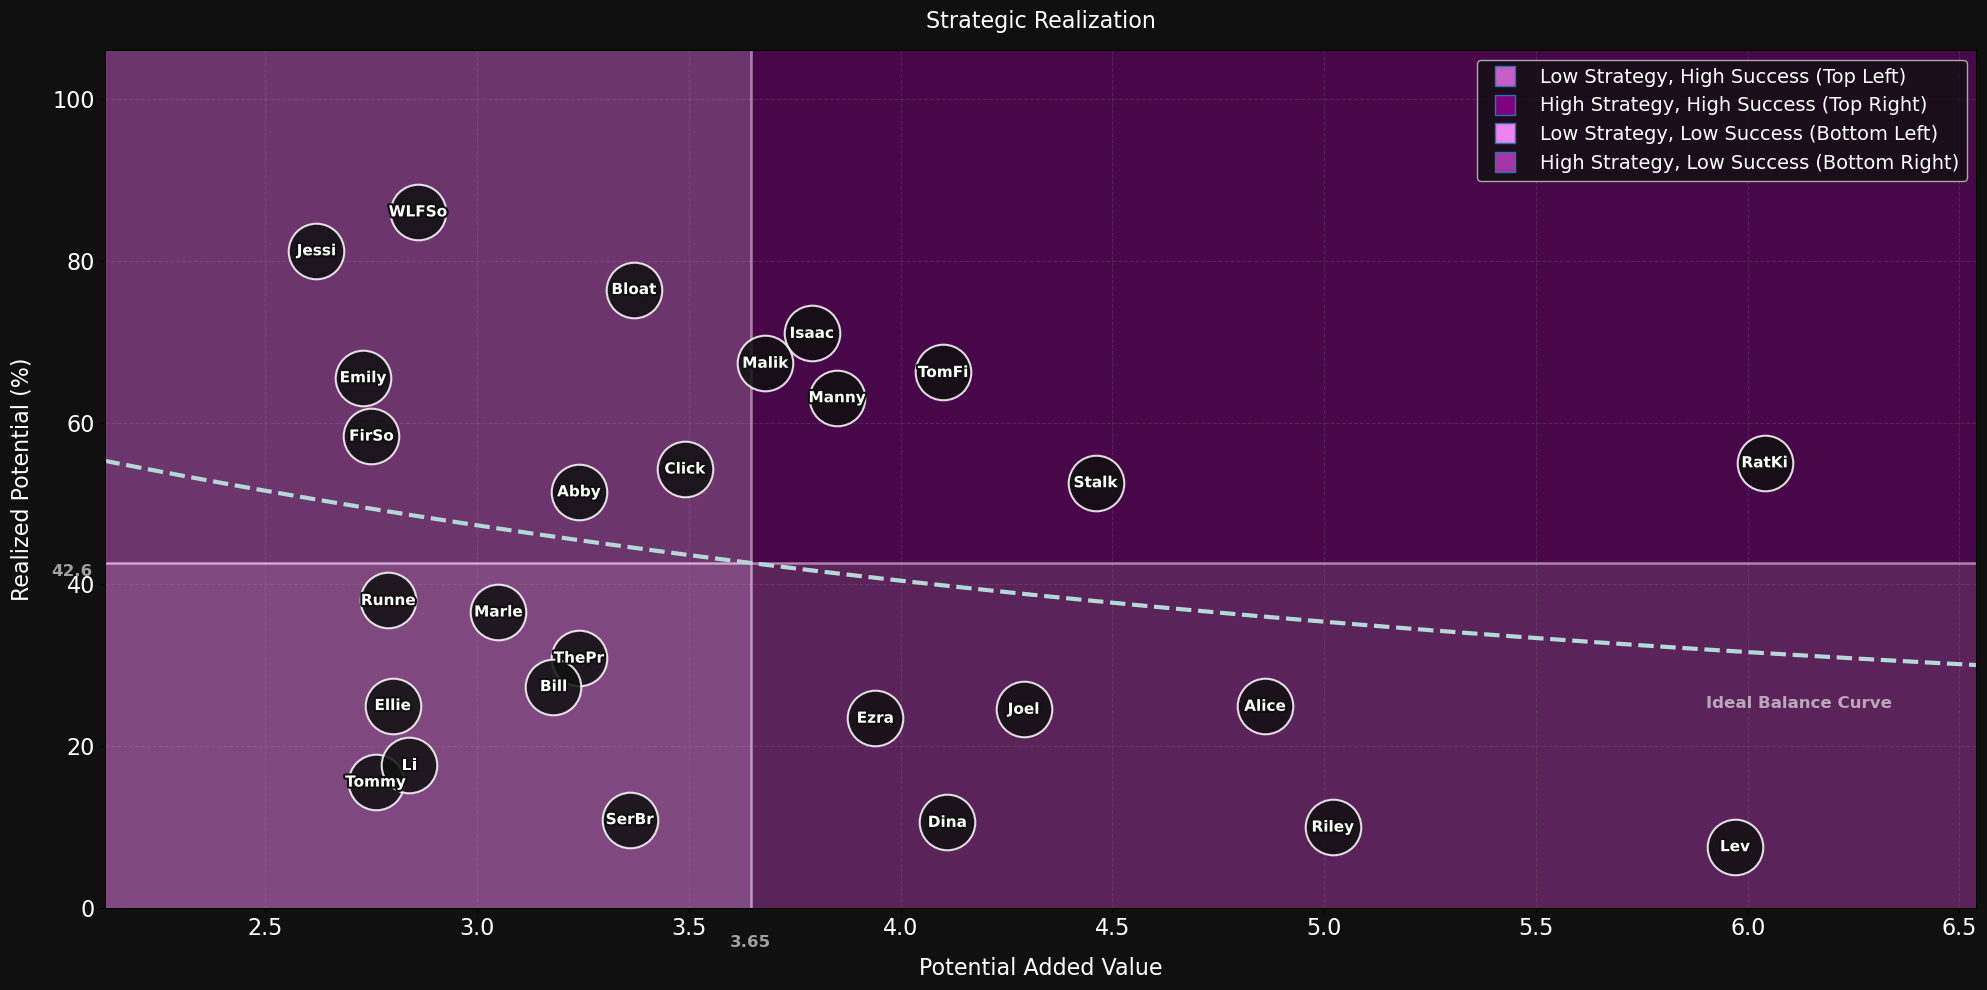

In [14]:
def generateShortName(characterName):
    words = re.sub('([a-z])([A-Z])', r'\1 \2', characterName).split()
    if len(words) > 1:
        return words[0][:3] + words[1][:2]
    else:
        return words[0][:5]

def plotStrategicRealizationMap(expectedValueResults, playedValueResults):
    # Calculate the X-Axis Center (Potential Add Mean)
    allSynergyValues = [item[3] for item in expectedValueResults]
    meanSynergyThreshold = np.mean(allSynergyValues)

    plotData = []
    for characterName, baseValue, expectedValue, valueAdded in expectedValueResults:
        averagePlayedValue = playedValueResults.get(characterName)
        
        if averagePlayedValue is not None:
            synergyDenominator = (expectedValue - baseValue) if (expectedValue - baseValue) != 0 else 0.1
            efficiencyPercentage = ((averagePlayedValue - baseValue) / synergyDenominator) * 100
            
            # Only plot cards at or above 0%
            if efficiencyPercentage >= 0:
                shortName = generateShortName(characterName)
                plotData.append((shortName, valueAdded, efficiencyPercentage))

    plt.figure(figsize=(20, 10), facecolor='#101010')
    currentAxes = plt.gca()
    currentAxes.set_facecolor('#101010')

    synergies = [d[1] for d in plotData]
    efficiencies = [d[2] for d in plotData]
    
    # Calculate the Y-Axis Center (Realization Mean)
    meanEfficiencyThreshold = np.mean(efficiencies)
    
    xMin, xMax = min(synergies) - 0.5, max(synergies) + 0.5
    yMin = 0
    yMax = max(efficiencies) + 20

    plt.xlim(xMin, xMax)
    plt.ylim(yMin, yMax)

    # Color the Regions using the Dynamic Center
    plt.fill_between([xMin, meanSynergyThreshold], meanEfficiencyThreshold, yMax, color="#c95dc8", alpha=0.5) # Top Left
    plt.fill_between([meanSynergyThreshold, xMax], meanEfficiencyThreshold, yMax, color="#800080", alpha=0.5) # Top Right
    plt.fill_between([xMin, meanSynergyThreshold], 0, meanEfficiencyThreshold, color="#ee82ee", alpha=0.5) # Bottom Left
    plt.fill_between([meanSynergyThreshold, xMax], 0, meanEfficiencyThreshold, color="#a436a3", alpha=0.5) # Bottom Right

    # Draw Threshold Lines
    plt.axvline(meanSynergyThreshold, color='white', linestyle='-', alpha=0.4, linewidth=2) # Vertical Mean
    plt.axhline(meanEfficiencyThreshold, color='white', linestyle='-', alpha=0.4, linewidth=2) # Horizontal Mean

    # Label the Vertical Mean (Potential Add)
    plt.text(meanSynergyThreshold - 0.05, yMin - 5.25, f"{meanSynergyThreshold:.2f}", 
             color='white', fontsize=12, alpha=0.6, ha='left', va='bottom', fontweight='bold')
             
    # Label the Horizontal Mean (Realized Potential)
    plt.text(xMin - 0.125, meanEfficiencyThreshold - 2, f"{meanEfficiencyThreshold:.1f}", 
             color='white', fontsize=12, alpha=0.6, ha='left', va='bottom', fontweight='bold')

    # The Target Balance Curve (The Ideal Mastery Asymptote)
    dynamicOffset = meanEfficiencyThreshold - (65 * np.exp(-0.3 * meanSynergyThreshold))

    curveX = np.linspace(xMin, xMax, 100)
    curveY = 65 * np.exp(-0.3 * curveX) + dynamicOffset
    
    plt.plot(curveX, curveY, color='#b2d8d8', linestyle='--', linewidth=3, alpha=1, zorder=2)
    plt.text(xMax -0.2, (65 * np.exp(-0.3 * meanSynergyThreshold)) + 2.5, 
             "Ideal Balance Curve", color='white', fontsize=12, 
             fontweight='bold', ha='right', va='bottom', alpha=0.6)  

    textOutline = [pathEffects.withStroke(linewidth=3, foreground='#101010')]

    for shortName, synergy, efficiency in plotData:
        plt.scatter(synergy, efficiency, color="#101010", s=1600, edgecolors='white', linewidth=1.5, alpha=0.85, zorder=3)
        
        textElement = plt.text(synergy, efficiency, shortName, color='white', 
                 fontsize=11, ha='center', va='center', fontweight='bold', zorder=4)
        textElement.set_path_effects(textOutline)

    # 6. Legend Styling
    legendElements = [
        plt.Line2D([0], [0], marker='s', linestyle='none', label='Low Strategy, High Success (Top Left)', markerfacecolor='#c95dc8', alpha=1, markersize=15),
        plt.Line2D([0], [0], marker='s', linestyle='none', label='High Strategy, High Success (Top Right)', markerfacecolor='#800080', alpha=1, markersize=15),
        plt.Line2D([0], [0], marker='s', linestyle='none', label='Low Strategy, Low Success (Bottom Left)', markerfacecolor='#ee82ee', alpha=1, markersize=15),
        plt.Line2D([0], [0], marker='s', linestyle='none', label='High Strategy, Low Success (Bottom Right)', markerfacecolor='#a436a3', alpha=1, markersize=15),
    ]

    plt.yticks(fontsize=16, color='white')
    plt.xticks(fontsize=16, color='white')
    plt.xlabel('Potential Added Value', fontsize=16, color='white', labelpad=12)
    plt.ylabel('Realized Potential (%)', fontsize=16, color='white', labelpad=14)
    plt.title('Strategic Realization', fontsize=16, color='white', pad=16)
    
    plt.grid(axis='both', linestyle='--', alpha=0.15)
    plt.legend(handles=legendElements, loc='upper right', frameon=True, facecolor="#101010", fontsize=14, labelcolor='white')

    plt.tight_layout()
    plt.savefig('finalGraphs/last_stand_strategic_realization.png', dpi=300)
    print(f"\nStrategic Realization report saved successfully as 'last_stand_strategic_realization.png'.")

plotStrategicRealizationMap(expectedValueData, playedValueData)

<h3>Explaining the Visualization</h3>

<h4>The Quadrants</h4>

| Quadrant | Profile | Player Experience |
| :--- | :--- | :--- |
| Top Left | Low Strategy, High Success | Cards that fall into this quadrant perform efficiently despite having limited synergy potential. They are reliable, consistent options that do not require complex setup. These cards tend to provide steady value and dependable outcomes. |
| Top Right | High Strategy, High Success | Cards in this quadrant successfully convert high synergy potential into strong real-world performance. These are skill-expressive cards that reward strategic planning and optimized play. They represent healthy synergy realization and often feel impactful when used correctly. |
| Bottom Left | Low Strategy, Low Success | Cards here have limited synergy potential and also demonstrate low realized performance. They function primarily as baseline or supporting pieces and contribute modestly to overall strategy. In moderation, this quadrant reflects necessary structural balance within the system. |
| Bottom Right | High Strategy, Low Success | Cards in this category possess significant synergy potential but show reduced realized performance. This may indicate activation difficulty, situational dependency, accessibility challenges, or meta underutilization. These cards have high theoretical depth but require favorable conditions to reach their full impact. |

The further right a card is, the higher the damage it can deal if played correctly.<br>
The further up a card is, the more likely it is to actually deal that additional damage.<br><br>

<p><b>What would an ideal system look like in terms of quadrants?</b></p><br>
In an ideal model, quadrants should be populated in descending order of performance, starting in the Top Right quadrant and moving anti-clockwise.
<ul>
<li> 40-60% of the total cards should be located in the Top Right.</li>
<li> 15-30% of the total cards should be located in the Top Left.</li>
<li> 10-20% of the total cards should be located in the Bottom Left.</li>
<li> 5-15% of the total cards should be located in the Bottom Right.</li>
</ul><br><hr>

<h4>The Ideal Balance Curve</h4>
To determine if a card is healthy, I evaluate it against the Target Mastery Asymptote:

$$y = 65e^{-0.3x} + C$$

Where:
- $x$ is the Potential Added Value. This is the maximum value a card can generate above its base stats in a simulated environment.
- $y$ is the Realized Potential (%). This measures how much of that theoretical synergy a human player actually captures in live play.
- $C$ is the Dynamic Efficiency Offset. It ensures the curve isn't static; it shifts up or down based on whether the overall game environment is becoming more optimized or more chaotic.
<br><br>

The exponential form reflects diminishing returns: as a card’s theoretical potential increases, perfect realization becomes increasingly difficult.<br><br>

| Position to Curve | Status | Design Desciption |
| :--- | :--- | :--- |
| Hugging the Curve | Balanced | The card is exactly where it needs to be. The mental effort required to play it perfectly matches the mechanical reward. |
| Significantly ABOVE the Curve | Overpowered | The card is generating too much value for how easy it is to execute. |
| Significantly BELOW the Curve | Frustrating | Players are putting in the strategic work but failing to get the payoff. The card is too difficult to execute in a real match. |

<h3>The Top 5</h3>

In [91]:
def calculatePerformanceRanking(expectedValueResults, playedValueResults):
    """
    Calculates a weighted performance score for each character.
    Weighting Strategy: 
    - 60% Total Power (Expected Value)
    - 20% Strategic Upside (Synergy Value Added)
    - 20% Execution Reality (Expected Value * Clamped Efficiency)
    """
    performanceReport = []

    for characterName, baseValue, expectedValue, synergyValueAdded in expectedValueResults:
        averagePlayedValue = playedValueResults.get(characterName)
        
        # 1. Efficiency Calculation: Measuring the realization of potential
        if averagePlayedValue is not None:
            # How much of the synergy 'stem' is the player actually climbing?
            synergyPotentialDenominator = (expectedValue - baseValue) if (expectedValue - baseValue) > 0 else 0.1
            realizedEfficiency = (averagePlayedValue - baseValue) / synergyPotentialDenominator
        else:
            # If no player data exists, assume a baseline 'average' performance (50%)
            realizedEfficiency = 0.5 
            
        # 2. Clamping for Statistical Integrity
        # We cap at 1.1 so that outlier exploits don't skew the results into impossible numbers
        clampedEfficiency = max(0, min(1.1, realizedEfficiency))
        
        # 3. Weighted Scoring Formula
        powerScore = expectedValue * 0.6
        synergyUpsideScore = synergyValueAdded * 0.2
        executionRealityScore = (expectedValue * clampedEfficiency) * 0.2
        
        finalPerformanceValue = powerScore + synergyUpsideScore + executionRealityScore
        
        performanceReport.append({
            "characterName": characterName,
            "performanceValue": round(finalPerformanceValue, 1),
            "expectedValue": round(expectedValue, 2),
            "efficiencyPercentage": round(realizedEfficiency * 100, 1)
        })

    # Sort characters by the final Performance Value in descending order
    return sorted(performanceReport, key=lambda character: character["performanceValue"], reverse=True)

In [92]:
# Optional: Run this to view the ranked table of performance
performanceRankingList = calculatePerformanceRanking(expectedValueData, playedValueData)

print(f"{'RANK':<5} | {'CHARACTER':<18} | {'PERFORMANCE':<12} | {'EV':<6} | {'EFFICIENCY'}")
print("-" * 65)

# Shows top 5
for rank, characterData in enumerate(performanceRankingList[:5], 1):
    print(f"{rank:<5} | "
          f"{characterData['characterName']:<18} | "
          f"{characterData['performanceValue']:<12} | "
          f"{characterData['expectedValue']:<6} | "
          f"{characterData['efficiencyPercentage']}%")

RANK  | CHARACTER          | PERFORMANCE  | EV     | EFFICIENCY
-----------------------------------------------------------------
1     | RatKing            | 11.1         | 13.97  | 55.7%
2     | Isaac              | 8.0          | 9.79   | 71.1%
3     | TheProphet         | 7.5          | 10.25  | 23.5%
4     | Joel               | 7.1          | 9.63   | 29.0%
5     | Abby               | 7.1          | 9.24   | 51.5%


In [ ]:
def calculateDeckShareRanking(characterSampleCounts):
    deckShareReport = []

    for characterName, plays in characterSampleCounts.items():
        deckShare = plays / totalDataPoints
        
        deckShareReport.append({
            "characterName": characterName,
            "plays": plays,
            "deckSharePercent": round(deckShare * 100, 2)
        })

    return sorted(deckShareReport, key=lambda c: c["deckSharePercent"], reverse=True)

In [93]:
# Optional: Run this to view the ranked table of deck share
deckShareRankingList = calculateDeckShareRanking(characterPlayCounts)

print(f"{'RANK':<5} | {'CHARACTER':<18} | {'PLAYS':<6} | {'DECK SHARE'}")
print("-" * 50)

# Shows top 5
for rank, characterData in enumerate(deckShareRankingList[:5], 1):
    print(f"{rank:<5} | "
          f"{characterData['characterName']:<18} | "
          f"{characterData['plays']:<6} | "
          f"{round((characterData['plays'] / totalDataPoints) * 100, 2)}%")

RANK  | CHARACTER          | PLAYS  | DECK SHARE
--------------------------------------------------
1     | Stalker            | 61     | 6.84%
2     | Runner             | 50     | 5.61%
3     | FireflySoldier     | 48     | 5.38%
4     | Clicker            | 47     | 5.27%
5     | SeraphiteBrute     | 41     | 4.6%
